In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
#Cargar data set limpio

ruta = "../data/clean/homeris-data-clean.csv"
df =  pd.read_csv(ruta)
df

,PERIODO,MUNICIPIO,DIAGNOSTICO,GENERO,REGIMEN,RANGO_EDAD,CANTIDAD_CASOS,ANIO,MES_NUM,PERIODO_MENSUAL,TRIMESTRE,MES_NOMBRE,SEMESTRE,GRUPO_DIAGNOSTICO,SALUD_MENTAL_CLASS
0,2024-01-01,ALCALA,OTROS TRASTORNOS DE ANSIEDAD,FEMENINO,CONTRIBUTIVO,60+,1,2024,1,2024-01,1,January,1,SALUD_MENTAL,SALUD_MENTAL
1,2024-01-01,ALCALA,PROBLEMAS RELACIONADOS CON EL GRUPO PRIMARIO D...,MASCULINO,SUBSIDIADO,29-59,1,2024,1,2024-01,1,January,1,FACTORES_SOCIALES,OTROS_GRUPOS_DX
2,2024-01-01,ALCALA,RETRASO MENTAL LEVE,MASCULINO,SUBSIDIADO,12-17,1,2024,1,2024-01,1,January,1,SALUD_MENTAL,SALUD_MENTAL
3,2024-01-01,ANSERMA,DORSALGIA,FEMENINO,SUBSIDIADO,29-59,1,2024,1,2024-01,1,January,1,MUSCULOESQUELETICO,OTROS_GRUPOS_DX
4,2024-01-01,ANSERMA,ESQUIZOFRENIA,MASCULINO,CONTRIBUTIVO,29-59,1,2024,1,2024-01,1,January,1,SALUD_MENTAL,SALUD_MENTAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14678,2024-11-01,VITERBO,TRASTORNOS DELIRANTES PERSISTENTES,MASCULINO,SUBSIDIADO,29-59,1,2024,11,2024-11,4,November,2,SALUD_MENTAL,SALUD_MENTAL
14679,2024-11-01,VITERBO,TRASTORNOS DISOCIATIVOS [ DE CONVERSION ],MASCULINO,CONTRIBUTIVO,29-59,1,2024,11,2024-11,4,November,2,SALUD_MENTAL,SALUD_MENTAL
14680,2024-11-01,VITERBO,TRASTORNOS ESPECIFICOS DEL DESARROLLO DE LAS H...,MASCULINO,CONTRIBUTIVO,6-11,1,2024,11,2024-11,4,November,2,SALUD_MENTAL,SALUD_MENTAL
14681,2024-11-01,VITERBO,TRASTORNOS FOBICOS DE ANSIEDAD,FEMENINO,CONTRIBUTIVO,29-59,1,2024,11,2024-11,4,November,2,SALUD_MENTAL,SALUD_MENTAL


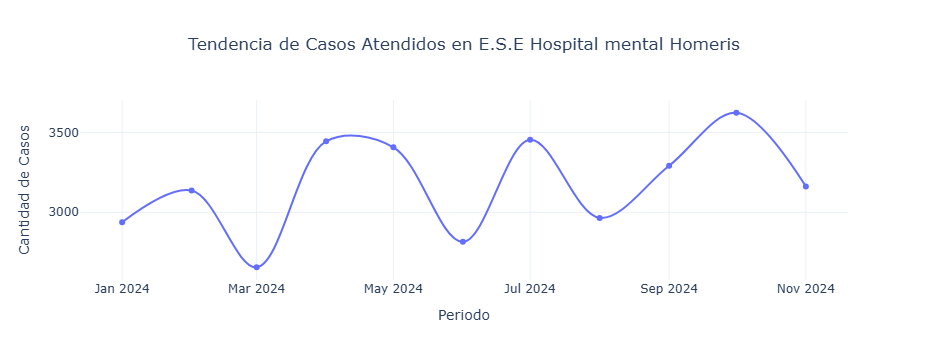

In [3]:
#Agrupamos 
df_group_period = df.groupby("PERIODO_MENSUAL")["CANTIDAD_CASOS"].sum().reset_index()

#Graficamos
fig = px.line(
    df_group_period,
    x="PERIODO_MENSUAL",
    y="CANTIDAD_CASOS",
    title="Tendencia de Casos Atendidos en E.S.E Hospital mental Homeris",
    markers=True
)

fig.update_traces(
    line_shape="spline", #Curva suave
    text=df_group_period["CANTIDAD_CASOS"],
    textposition="top center",
    hovertemplate="<b>Periodo:</b> %{x}<br><b>Casos:</b> %{y}<extra></extra>"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Periodo",
    yaxis_title="Cantidad de Casos"
)

fig.show()

In [4]:
print(f"{df['CANTIDAD_CASOS'].sum()}")

34891


In [5]:
df['CANTIDAD_CASOS'].unique()

array([ 1,  2,  3,  5,  8, 14,  6,  7,  4, 16, 13, 12, 18, 15, 11, 10,  9,
       36, 20, 17, 62, 42, 29, 19, 21, 63, 46, 22, 37, 45, 23, 50, 28, 34,
       60, 44, 26, 49, 40, 43, 38, 31, 58, 33, 57, 47, 27, 24, 39, 61, 32,
       52, 48, 55, 25, 75, 51, 41, 35, 53, 30, 65, 54])

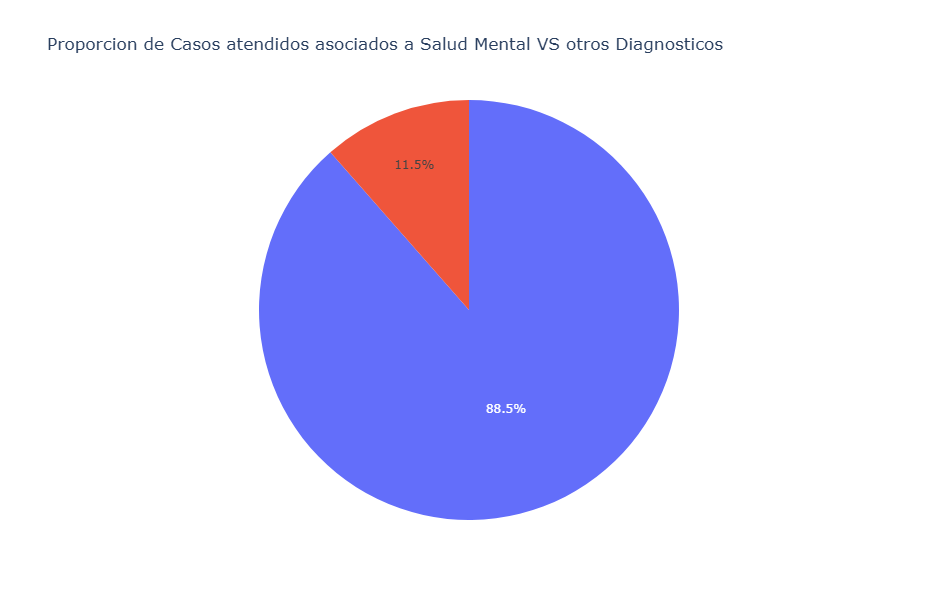

In [6]:
df_group_salud_mental = df.groupby("SALUD_MENTAL_CLASS")["CANTIDAD_CASOS"].sum().reset_index()

fig_group_salud_mental = px.pie(df_group_salud_mental, values="CANTIDAD_CASOS",
                                title="Proporcion de Casos atendidos asociados a Salud Mental VS otros Diagnosticos",
                                width=800,
                                height=600
                               )
fig_group_salud_mental.show()

In [7]:
df.columns

Index(['PERIODO', 'MUNICIPIO', 'DIAGNOSTICO', 'GENERO', 'REGIMEN',
       'RANGO_EDAD', 'CANTIDAD_CASOS', 'ANIO', 'MES_NUM', 'PERIODO_MENSUAL',
       'TRIMESTRE', 'MES_NOMBRE', 'SEMESTRE', 'GRUPO_DIAGNOSTICO',
       'SALUD_MENTAL_CLASS'],
      dtype='object')

In [8]:
print(df[["GRUPO_DIAGNOSTICO", "SALUD_MENTAL_CLASS"]].head(20))


           GRUPO_DIAGNOSTICO SALUD_MENTAL_CLASS
0               SALUD_MENTAL       SALUD_MENTAL
1          FACTORES_SOCIALES    OTROS_GRUPOS_DX
2               SALUD_MENTAL       SALUD_MENTAL
3         MUSCULOESQUELETICO    OTROS_GRUPOS_DX
4               SALUD_MENTAL       SALUD_MENTAL
5               SALUD_MENTAL       SALUD_MENTAL
6               SALUD_MENTAL       SALUD_MENTAL
7               SALUD_MENTAL       SALUD_MENTAL
8   CONTACTO_SERVICIOS_SALUD    OTROS_GRUPOS_DX
9               SALUD_MENTAL       SALUD_MENTAL
10              SALUD_MENTAL       SALUD_MENTAL
11              SALUD_MENTAL       SALUD_MENTAL
12              SALUD_MENTAL       SALUD_MENTAL
13              SALUD_MENTAL       SALUD_MENTAL
14      ENDOCRINO_METABOLICO    OTROS_GRUPOS_DX
15              SALUD_MENTAL       SALUD_MENTAL
16               NEUROLOGICO    OTROS_GRUPOS_DX
17              SALUD_MENTAL       SALUD_MENTAL
18              SALUD_MENTAL       SALUD_MENTAL
19              SALUD_MENTAL       SALUD

In [9]:
fig_g_dx_top = px.treemap(
    df,
    path=["GRUPO_DIAGNOSTICO","DIAGNOSTICO"],
    values="CANTIDAD_CASOS",
    title="Proporción de casos por grupo diagnóstico",
    height=1000,   # más alto
    width=1000     # menos ancho
)
fig_g_dx_top.show()

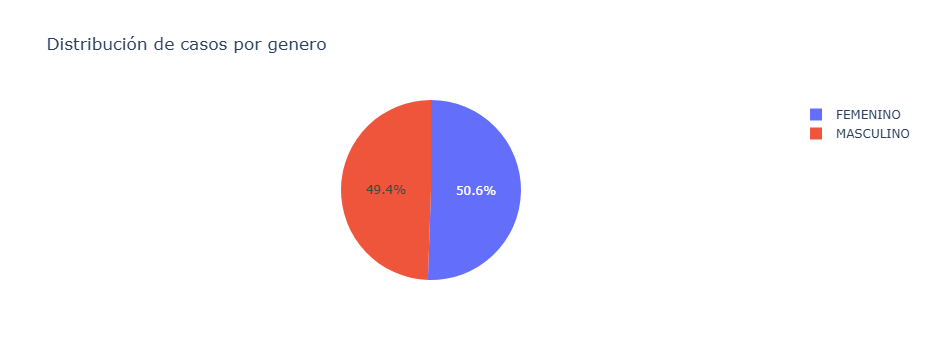

In [13]:
df_genero  = (
    df.groupby('GENERO')['CANTIDAD_CASOS']
    .sum()
    .reset_index()
)
fig_genero = px.pie(
    df_genero,
    names='GENERO',
    values='CANTIDAD_CASOS',
    title= "Distribución de casos por genero"
)
fig_genero.show()


In [14]:
df['RANGO_EDAD'].value_counts()
    

RANGO_EDAD
29-59    5132
60+      3017
18-28    2582
12-17    2442
6-11     1147
0-5       363
Name: count, dtype: int64